# PPG Heart Rate Estimation with S4

Train S4 model on PPG dataset for continuous heart rate estimation.

This notebook follows a standard regression workflow:
- **Task**: Predict heart rate (bpm) from PPG windows
- **Model**: S4-based sequence model
- **Training**: MSE loss with MAE tracking
- **Evaluation**: Test set performance (MAE, RMSE)


In [4]:
from typing import Dict, Any
from pathlib import Path
import torch

from src.datasets.ppg.ppg_config import PPGDaliaConfig

## Verify Shape Fix

This cell verifies that the data loader and model output compatible shapes.

In [5]:
print("=" * 60)
print("SHAPE VERIFICATION")
print("=" * 60)

# Quick test to verify shapes
from src.datasets.ppg.ppg_dataset import PPGDaliaDataset
from src.datasets.ppg.ppg_dataloader import ppg_collate

current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent  # from src/notebooks/ppg to project root
data_root = str(project_root / "src" / "datasets" / "ppg" / "data")


# Create a tiny test dataset
test_cfg = PPGDaliaConfig(
    root=data_root,
    subjects_train=("S1",),
    fs_in=64.0, fs=100.0, win_sec=8, stride_sec=2,
    do_bandpass=True, low_hz=0.5, high_hz=8.0, split='train'
)

test_ds = PPGDaliaDataset(test_cfg)

# Get a batch
batch = [test_ds[i] for i in range(min(4, len(test_ds)))]
x_batch, y_batch, _ = ppg_collate(batch)

print(f"✅ Batch x shape: {tuple(x_batch.shape)} (expected: [B, T, 1])")
print(f"✅ Batch y shape: {tuple(y_batch.shape)} (expected: [B])")

if y_batch.ndim == 1:
    print("✅ Target shape is correct: [B] for regression")
elif y_batch.shape[-1] == 1 and y_batch.ndim == 2:
    print("❌ Target shape is [B, 1] but should be [B]")
    print("   → Restart kernel and run again")
else:
    print(f"❌ Unexpected target shape: {tuple(y_batch.shape)}")

print("=" * 60)


SHAPE VERIFICATION
✅ Batch x shape: (4, 800, 4) (expected: [B, T, 1])
✅ Batch y shape: (4,) (expected: [B])
✅ Target shape is correct: [B] for regression


## Task Definition

Import shared PPGTask from `src.tasks.ppg_task` to avoid code duplication.

In [6]:
from src.notebooks.ppg.ppg_task import PPGTask

## Block Configuration Helper

Import S4 block config helper from `src.utils.block_configs` to avoid code duplication.

In [7]:
from src.utils.block_configs import create_s4_block_cfg_ctor

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


## Configuration

**IMPORTANT**: Update `TRAIN_SUBJECTS`, `VAL_SUBJECT`, and `TEST_SUBJECT` to match your actual dataset subject IDs.

Place your PPG data in: `src/datasets/ppg/data/`

Expected structure:
```
data/
  S1/
    S1.pkl
  S2/
    S2.pkl
  ...
```

Each pickle file should contain:
- `signal['wrist']['BVP']`: PPG signal
- `label`: HR labels (bpm)


In [8]:
# Example subject split - ADJUST TO YOUR DATASET
TRAIN_SUBJECTS = ("S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8")
VAL_SUBJECT = "S9"
TEST_SUBJECT = "S10"

args: Dict[str, Any] = {
    # Data
    "data_root": data_root,
    "batch": 32,  # Reduced for MPS memory
    "data_loader_kwargs": {
        "num_workers": 0,
        "pin_memory": False,
        "persistent_workers": False,
        # PPGDaliaConfig parameters
        "subjects_train": TRAIN_SUBJECTS,
        "subject_val": VAL_SUBJECT,
        "subject_test": TEST_SUBJECT,
        "fs_in": 64.0,        # Input sampling rate (Hz)
        "fs": 100.0,          # Target sampling rate (Hz)
        "win_sec": 8,         # Window length (seconds)
        "stride_sec": 2,      # Stride (seconds)
        "do_bandpass": True,
        "low_hz": 0.5,
        "high_hz": 8.0,
    },

    # Training
    "epochs": 100,
    "lr": 5e-4,
    "wd": 1e-4,
    "amp": False,  # Disable AMP for MPS stability
    "save_dir": "./runs/ppg_s4_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.01,  # MAE improvement threshold

    # Model (reduced for MPS memory)
    "d_model": 128,      # Reduced from 256
    "depth": 4,          # Reduced from 6
    "dropout": 0.2,
    "mlp_ratio": 2.0,
    "droppath_final": 0.1,
    "layerscale_init": 1e-2,
    "residual_gain": 1.0,
    "pool": "mean",

    # S4-specific hyperparameters
    "d_state": 64,
    "mode": "s4d",           # 's4d', 's4', or 'diag'
    "bidirectional": False,  # Use bidirectional S4
}

args["block_cfg_ctor"] = create_s4_block_cfg_ctor(
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
    d_state=args["d_state"],
    mode=args["mode"],
    bidirectional=args["bidirectional"],
)

# Device selection
import os

if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    # Set MPS memory management BEFORE any operations
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"
    torch.mps.set_per_process_memory_fraction(0.7)
    print("🚀 Using MPS (Apple Silicon) with reduced memory")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
    print("🚀 Using CUDA")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False
    print("⚠️  Using CPU")

print(f"\n📂 Data root: {args['data_root']}")
print(f"🎯 Train subjects: {TRAIN_SUBJECTS}")
print(f"🎯 Val subject: {VAL_SUBJECT}")
print(f"🎯 Test subject: {TEST_SUBJECT}")
print(f"\n🔧 S4 Configuration:")
print(f"   d_state: {args['d_state']}")
print(f"   mode: {args['mode']}")
print(f"   bidirectional: {args['bidirectional']}")


🚀 Using MPS (Apple Silicon) with reduced memory

📂 Data root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/datasets/ppg/data
🎯 Train subjects: ('S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8')
🎯 Val subject: S9
🎯 Test subject: S10

🔧 S4 Configuration:
   d_state: 64
   mode: s4d
   bidirectional: False


## Training

In [ ]:
from src.train_utils.trainer import Trainer

# Define the task
task = PPGTask()

# Initialize trainer
trainer = Trainer(args=args, task=task)

# Train
best_metric, best_path = trainer.fit()

history = trainer.history

print(f"\n✅ Training complete! Best validation {trainer.early_key}: {best_metric:.4f}")
print(f"💾 Best model saved to: {best_path}")

## Plot History

In [9]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="train_loss", linewidth=2)
    plt.plot(history["val_loss"], label="val_loss", linewidth=2)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("MSE Loss", fontsize=12)
    plt.legend(fontsize=11)
    plt.title("Training & Validation Loss (S4)", fontsize=14)
    plt.grid(True, alpha=0.3)

    # MAE
    plt.subplot(1, 2, 2)
    plt.plot(history["train_mae"], label="train_mae", linewidth=2)
    plt.plot(history["val_mae"], label="val_mae", linewidth=2)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("MAE (bpm)", fontsize=12)
    plt.legend(fontsize=11)
    plt.title("Mean Absolute Error (S4)", fontsize=14)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Test Evaluation

Import shared evaluation function from local `ppg_eval.py` to avoid code duplication.

In [10]:
from ppg_eval import evaluate_best_model

# Run evaluation
preds, targets = evaluate_best_model(
    args=args,
    task=PPGTask(),
    best_model_path=args["save_dir"] + "/best.pt"
)

📊 Evaluating best model on the test set...
✅ Loaded checkpoint from epoch 20
📈 Val MSE: 119.1143, Val MAE: 7.4365


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: divide by zero encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: overflow encountered in matmul
  A = T @ M @ np.linalg.inv(T)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/src/models/s4/s4_block.py:322: RuntimeWarning: invalid value encountered in matmul
  A = T @ M @ np.linalg.inv(T)


Testing:   0%|          | 0/167 [00:00<?, ?it/s]


TEST SET RESULTS:
MSE:  85.9733
MAE:  4.8143 bpm
RMSE: 9.2722 bpm


In [11]:
from src.utils.common import print_model_details

print_model_details(model=trainer.model)

NameError: name 'trainer' is not defined

## Prediction Visualization

In [ ]:
import matplotlib.pyplot as plt

# Plot predictions vs targets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax = axes[0]
ax.scatter(targets, preds, alpha=0.5, s=10)
lims = [min(targets.min(), preds.min()) - 5, max(targets.max(), preds.max()) + 5]
ax.plot(lims, lims, 'r--', alpha=0.75, linewidth=2, label='Perfect prediction')
ax.set_xlabel('True HR (bpm)', fontsize=12)
ax.set_ylabel('Predicted HR (bpm)', fontsize=12)
ax.set_title('S4: Predictions vs Ground Truth', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Error distribution
ax = axes[1]
errors = preds - targets
ax.hist(errors, bins=50, alpha=0.75, edgecolor='black')
ax.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero error')
ax.set_xlabel('Prediction Error (bpm)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('S4: Error Distribution', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nError Statistics:")
print(f"  Mean Error: {errors.mean():.4f} bpm (bias)")
print(f"  Std Error:  {errors.std():.4f} bpm")
print(f"  95% of predictions within: ±{1.96 * errors.std():.2f} bpm")


## Changes in datasets length


🔄 Training with fraction: 0.5
📊 Applying data fraction: 50.0%
   Original train size: 33617
   Original val size: 4277
   Reduced train size: 16808
   Reduced val size: 2138
   Test size: 5321 (unchanged)


💾 saved best model to ./runs/ppg_s4_task_frac_50/best.pt
✅ new best mse 7987.8867
Epoch 000/100 | train 8915.7113/8915.7113 | val 7987.8867/7987.8867 | t 165.9s/6.0s | lr 5.00e-07


💾 saved best model to ./runs/ppg_s4_task_frac_50/best.pt
✅ new best mse 5929.4456
Epoch 001/100 | train 7658.2842/7658.2842 | val 5929.4456/5929.4456 | t 179.6s/6.8s | lr 1.00e-04


💾 saved best model to ./runs/ppg_s4_task_frac_50/best.pt
✅ new best mse 3369.8907
Epoch 002/100 | train 5424.6236/5424.6236 | val 3369.8907/3369.8907 | t 182.5s/6.8s | lr 2.00e-04


💾 saved best model to ./runs/ppg_s4_task_frac_50/best.pt
✅ new best mse 585.4795
Epoch 003/100 | train 2280.0011/2280.0011 | val 585.4795/585.4795 | t 182.9s/6.8s | lr 3.00e-04


...

Epoch 021/100 | train 56.1984/56.1984 | val 172.8392/172.8392 | t 186.3s/7.0s | lr 4.66e-04


Epoch 022/100 | train 51.9250/51.9250 | val 230.2092/230.2092 | t 186.4s/7.0s | lr 4.62e-04


Epoch 023/100 | train 50.7056/50.7056 | val 179.2474/179.2474 | t 186.7s/7.0s | lr 4.57e-04


Epoch 024/100 | train 48.7091/48.7091 | val 193.1547/193.1547 | t 186.7s/7.0s | lr 4.52e-04


⏹ Early stopping (patience=5, best=145.4263).
📊 Training history saved to ./runs/ppg_s4_task_frac_50/history.json

✅ Training complete for fraction 0.5! Best validation mse: 145.4263
💾 Best model saved to: ./runs/ppg_s4_task_frac_50/best.pt


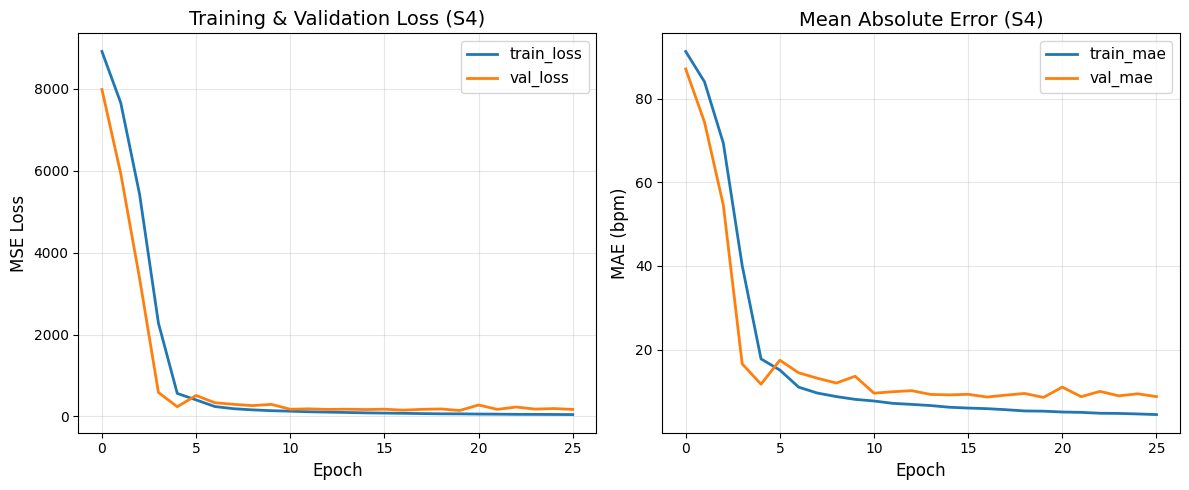

📊 Evaluating best model on the test set...
✅ Loaded checkpoint from epoch 19
📈 Val MSE: 145.4263, Val MAE: 8.5853


Testing:   0%|          | 0/167 [00:00<?, ?it/s]


TEST SET RESULTS:
MSE:  114.3843
MAE:  6.9746 bpm
RMSE: 10.6951 bpm


In [10]:
from src.train_utils.trainer import Trainer
from ppg_eval import evaluate_best_model

for frac in [0.1, 0.25, 0.5]:

    print(f"\n🔄 Training with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/ppg_s4_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=PPGTask())
    best_metric, best_path = trainer.fit()

    print(f"\n✅ Training complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"💾 Best model saved to: {best_path}")

    history = trainer.history

    plot_history(history)

    preds, targets = evaluate_best_model(
        args=args,
        task=PPGTask(),
        best_model_path=best_path
    )